# Explicit graph embedding

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import heapq

In [ ]:
g1 = nx.Graph()
g1.add_node(0,node_label = "A")
g1.add_node(1,node_label = "B")
g1.add_node(2,node_label = "A")
g1.add_node(3,node_label = "C")
g1.add_edge(0,1,edge_label = "a")
g1.add_edge(1,2,edge_label = "a")
g1.add_edge(2,3,edge_label = "b")
g1.add_edge(3,1,edge_label = "b")

g2 = nx.Graph()
g2.add_node(0,node_label = "B")
g2.add_node(1,node_label = "A")
g2.add_node(2,node_label = "A")
g2.add_edge(0,1,edge_label = "a")
g2.add_edge(1,2,edge_label = "b")

(<Axes: >, <Axes: >)

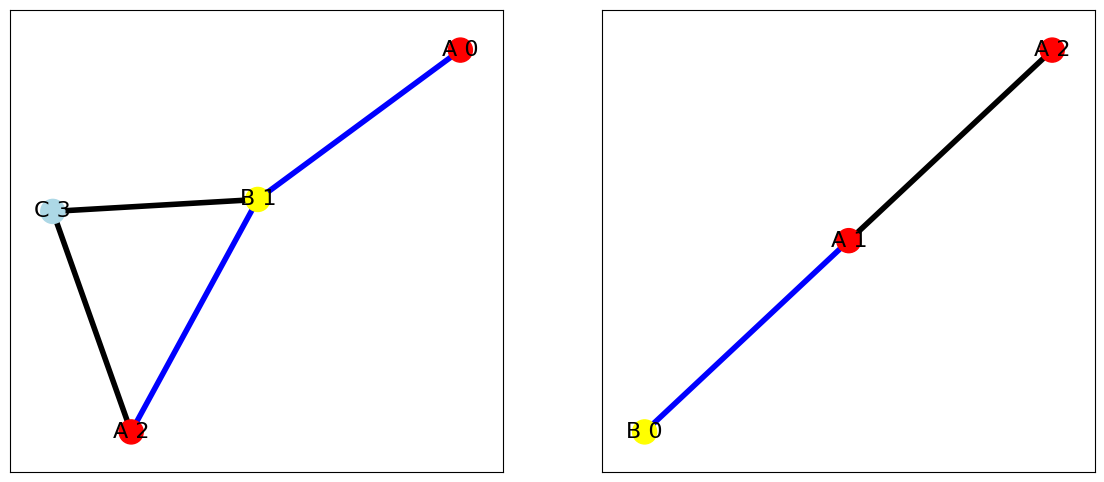

In [ ]:
def draw_pair_graph(graph1,graph2, weight="distance_l2"):
    label1 = {k:lab['node_label']+' '+str(k) for k,lab in graph1.nodes(data=True)}
    label2 = {k:lab['node_label']+' '+str(k) for k,lab in graph2.nodes(data=True)}

    subset_color = [
    "red", #carbone
    "yellow", #azote
    "lightblue"] #oxygène
    dic = {'A' :0, 'B':1, 'C':2}
    dic2 = {'a' :0, 'b':1}

    subset_color_edge = [
    "blue", #simple liaison
    "black", #double liaison
    "darkorange"] #triple liaison

    fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(14, 6))

    color = [subset_color[dic[data['node_label']]] for v, data in graph1.nodes(data=True)]
    color_edge = [subset_color_edge[dic2[data['edge_label']]] for n1,n2, data in graph1.edges(data=True)]
    position = nx.spring_layout(graph1, weight=weight)

    nx.draw_networkx_nodes(graph1, position, node_color=color, alpha = 1, ax=ax1)
    nx.draw_networkx_edges(graph1, position, edge_color=color_edge,width=4, alpha =1 , ax=ax1)
    nx.draw_networkx_labels(graph1, position, label1, font_size=16, ax=ax1)

    color = [subset_color[dic[data['node_label']]] for v, data in graph2.nodes(data=True)]
    color_edge = [subset_color_edge[dic2[data['edge_label']]] for n1,n2, data in graph2.edges(data=True)]
    position = nx.spring_layout(graph2, weight=weight)

    nx.draw_networkx_nodes(graph2, position, node_color=color, alpha = 1, ax=ax2)
    nx.draw_networkx_edges(graph2, position, edge_color=color_edge,width=4, alpha =1 , ax=ax2)
    nx.draw_networkx_labels(graph2, position, label2, font_size=16, ax=ax2)
    return ax1,ax2


draw_pair_graph(g1,g2)

### 1) Only count the number of vertices for each possible label value

In [ ]:
def Emb_Nodes(G):
  dic = {'C' :0, 'O':1, 'N':2, 'S':3, 'Cl':4}
  emb = np.zeros(len(dic))

  for node, data in G.nodes(data=True):
    emb[dic[data['node_label']]] +=1

  return emb


In [ ]:
print(f"Embedding G1 = {Emb_Nodes(G1)}")
print(f"\nEmbedding G2 = {Emb_Nodes(G2)}")

Embedding G1 = [8. 4. 1. 1. 0.]

Embedding G2 = [13.  2.  2.  0.  2.]


### 2) Add the number of edges with two specific labels at end vertices

This function returns an embedding of a graph, it returns an array with the number of nodes of each label among three options. The problem is that I had to define a dictionary to do that, and that is no recommended, because new labels might appear and it set the embedding to size 3 even if there are less label types.

Write a new function to create a similar embedding of a graph.Where it counts the number of vertices for each possible label value

def Emb_Nodes(G):
  dic = {'A' :0, 'B':1, 'C':2}
  emb = np.zeros(len(dic))

  for node, data in G.nodes(data=True):
    emb[dic[data['node_label']]] +=1

  return emb

In [ ]:
import pandas as pd
import networkx as nx
from rdkit import Chem
from rdkit.Chem import AllChem

def smiles_to_networkx(smiles):
    # Convert molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid: {smiles}")
    graph = nx.Graph()
    AllChem.Compute2DCoords(mol)
    # Creating nodes
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        pos = mol.GetConformer().GetAtomPosition(idx)
        graph.add_node(
            atom.GetIdx(),
            symbol=atom.GetSymbol(),
            node_label=atom.GetSymbol(),
            position=(round(pos.x, 4), round(pos.y, 4))
        )
    # Creating edges
    for bond in mol.GetBonds():
        graph.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
        )
    return graph

In [ ]:
G1 = smiles_to_networkx("COC(=O)c1ccccc1S(=O)(=O)N")
G2 = smiles_to_networkx("Cc1[nH+]ccn1C[C@H](COc1ccc(cc1Cl)Cl)O")

In [ ]:
# display molecule graph
def display_molecule_graph(mol, mask_graph, colors=None):

    mask_graph_atom_key = list(mask_graph['atom'].keys())
    mask_graph_bond_key = list(mask_graph['bond'].keys())

    mask_graph_color = copy.deepcopy(mask_graph)
    colors = colors

    for i in mask_graph_color['atom']:
        color = colors[mask_graph_color['atom'][i]]
        mask_graph_color['atom'][i] = tuple(color)
    for i in mask_graph_color['bond']:
        color = colors[mask_graph_color['bond'][i]]
        mask_graph_color['bond'][i] = tuple(color)

    rdDepictor.Compute2DCoords(mol)
    dg = rdMolDraw2D.MolDraw2DSVG(1050, 1000)
    dg.SetFontSize(6)

    mol = rdMolDraw2D.PrepareMolForDrawing(mol)
    dg.DrawMolecule(mol,
                    highlightAtoms=mask_graph_atom_key,
                    highlightAtomColors=mask_graph_color['atom'],
                    highlightBonds=mask_graph_bond_key,
                    highlightBondColors=mask_graph_color['bond'])

    dg.FinishDrawing()
    svg = dg.GetDrawingText()
    svg = svg.replace('svg:', '')
    svg = svg.replace("<rect style='opacity:1.0", "<rect style='opacity: 0")
    svg2png(bytestring=svg, write_to='tmp_graph.png', dpi=300, background_color='transparent')
    img = imread('tmp_graph.png')
    os.remove('tmp_graph.png')
    return img

# display molecule reduced graph
def display_molecule_reduced(mol, mask_graph, edges, mol_pos=None, colors=None):

    mask_graph_atom_key = list(mask_graph['atom'].keys())
    mask_graph_bond_key = list(mask_graph['bond'].keys())

    mask_graph_color = copy.deepcopy(mask_graph)
    colors = colors

    mol_nx = g_to_nx(mask_graph_atom_key, edges)

    mol_pos = mol_pos
    mol_node = nx.get_node_attributes(mol_nx, 'idx')
    mol_colors = colors

    fig = plt.figure(figsize=(10,10))
    plt.clf()
    nx.draw(mol_nx,
            pos=mol_pos,
            labels=mol_node,
            with_labels=True,
            node_color=mol_colors,
            node_size=3000,
            font_size='20')

    plt.savefig('tmp_reduced.png', dpi=300, transparent=True)
    plt.close(fig)
    img = plt.imread('tmp_reduced.png')
    os.remove('tmp_reduced.png')
    return img

def display_img(moleculegraph, colors=None):
    mol = moleculegraph['mol']
    cliques = moleculegraph['cliques']
    edges = moleculegraph['edges']

    # formatting mol
    mol = mol_with_atom_index(mol)
    AllChem.Compute2DCoords(mol)
    number_of_sub = len(cliques)

    if colors is None:
        # random colors
        colors = []
        for i in range(number_of_sub):
            r = random.randint(0,255)/255
            g = random.randint(0,255)/255
            b = random.randint(0,255)/255
            colors.append([r,g,b,1])

    # construct mask graph
    mask_graph = {}
    mask_graph['atom'] = {}
    mask_graph['bond'] = {}
    for i, c in enumerate(cliques):
        for a in c:
            # should have multiple
            # mask_graph['atom'].append({a: i})
            mask_graph['atom'][a] = i
            for j, b in enumerate(mol.GetBonds()):
                if all(bb in c for bb in [b.GetBeginAtomIdx(), b.GetEndAtomIdx()]):
                    mask_graph['bond'][j] =  i

    # construct mast subgraph
    mask_subgraph = {}
    mask_subgraph['atom'] = {}
    mask_subgraph['bond'] = {}
    for i, e in enumerate(cliques):
        mask_subgraph['atom'][i] = i
        mask_subgraph['atom'][i] = i

    # compute position
    mol_con = [c.GetPositions()[:,:2] for c in mol.GetConformers()][0]
    mol_pos_node = {i: c for i, c in enumerate(mol_con)}
    mol_pos = dict()
    for i_c, c in enumerate(cliques):
        b_pos_x = 0
        b_pos_y = 0
        b_num = 0
        for n in c:
            b_pos_x += mol_pos_node[n][0]
            b_pos_y += mol_pos_node[n][1]
            b_num += 1
        if b_num != 0:
            mol_pos[i_c] = [b_pos_x/b_num, b_pos_y/b_num]

    img_graph = display_molecule_graph(mol, mask_graph, colors=colors)
    img_reduced = display_molecule_reduced(mol, mask_subgraph, edges, mol_pos=mol_pos, colors=colors)

    return img_graph, img_reduced

def display_alignment(moleculegraph, alignment='horizontal', colors=None):
    img_graph, img_reduced = display_img(moleculegraph, colors=colors)

    # visualize
    if alignment == 'horizontal':
        fig, ax = plt.subplots(1, 2, figsize=(15,7))
        plt.clf()
    elif alignment == 'vertical':
        fig, ax = plt.subplots(2, 1, figsize=(7,15))
        plt.clf()

    # ax setting
    if alignment == 'horizontal':
        ax1 = plt.subplot(1, 2, 1)
    elif alignment == 'vertical':
        ax1 = plt.subplot(2, 1, 1)

    ax1.grid(False)
    ax1.axis('off')
    ax1.imshow(img_graph)

    # ax setting
    if alignment == 'horizontal':
        ax2 = plt.subplot(1, 2, 2)
    elif alignment == 'vertical':
        ax2 = plt.subplot(2, 1, 2)

    ax2.grid(False)
    ax2.axis('off')
    ax2.imshow(img_reduced)

    plt.tight_layout()
    fig.savefig('tmp_combine.png', dpi=300)
    plt.close(fig)
    img = plt.imread('tmp_combine.png')
    os.remove('tmp_combine.png')
    return img

def display_one_graph(moleculegraph, alignment='horizontal', colors=None):
    if alignment == 'horizontal':
        fig, ax = plt.subplots(1, 1, figsize=(15,7), dpi=300)
    elif alignment == 'vertical':
        fig, ax = plt.subplots(1, 1, figsize=(7,15), dpi=300)
    ax1 = plt.subplot(1, 1, 1)
    ax1.grid(False)
    ax1.axis('off')
    ax1.imshow(display_alignment(moleculegraph, alignment=alignment, colors=colors))



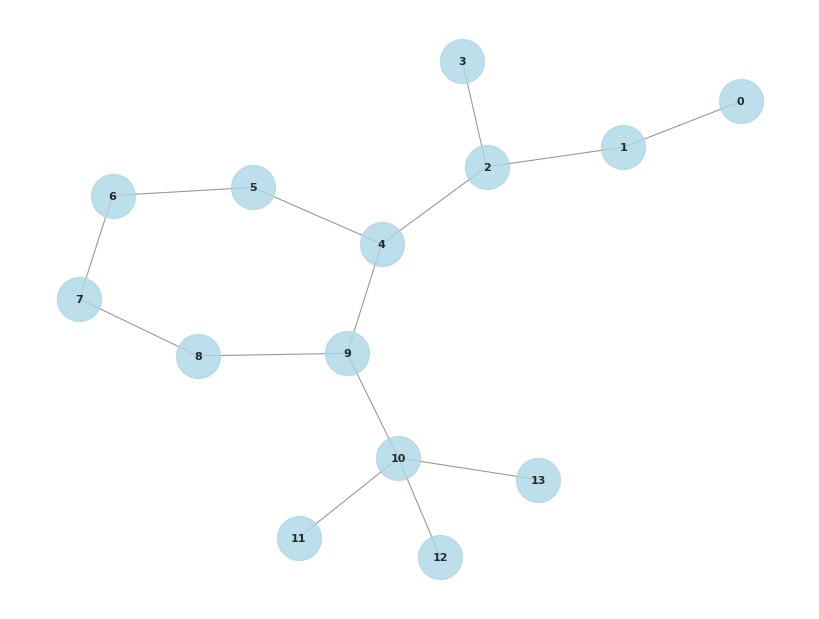

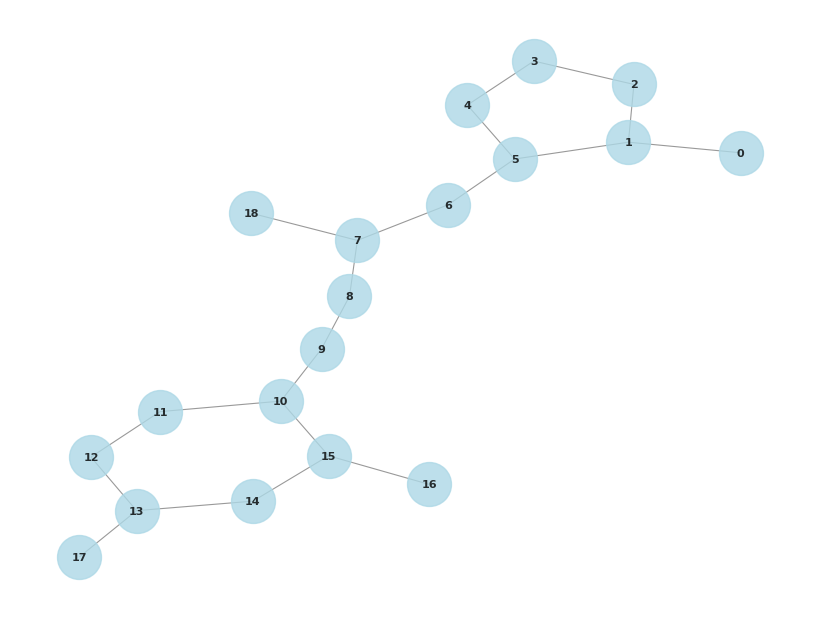

In [ ]:
def PlotGraph(G):
    pos = nx.kamada_kawai_layout(G)

    plt.figure(figsize=(8, 6))

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=1000,
        node_color='lightblue',
        font_size=8,
        font_weight='bold',
        edge_color='gray',
        width=0.8,
        alpha=0.8
    )

    edge_labels = {}
    for u, v, data in G.edges(data=True):
        w = data.get('weight', '')
        if (u, v) in edge_labels:
            edge_labels[(u, v)] += f",{str(w)}"
        else:
            edge_labels[(u, v)] = str(w)

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
    plt.show()

PlotGraph(G1)
PlotGraph(G2)